In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

sns.set_context("talk")
sns.set_style("whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Shared plotting helper

In [2]:
def plot_publication_stacked_barh(
    df_pivot,
    title,
    colors,
    labels_map=None,
    figsize=(8.6, 3.8),
    inside_threshold=0.08,
    outside_offset=0.010,
    percent_decimals=1,
    bar_height=0.72,
    legend=True,
    legend_title=None,
    x_label="Fraction of cells",
    small_label_vertical_shift=-0.24,
    title_pad=10,
    save_path=None,
    dpi=300,
):
    """
    Horizontal stacked bar chart for publication-style proportion plots.

    Parameters
    ----------
    df_pivot : pd.DataFrame
        Rows = bars, columns = categories, values = fractions summing to ~1 per row.
    labels_map : dict or None
        Optional mapping from internal category names to display labels.
    """

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(df_pivot))
    left = np.zeros(len(df_pivot))

    for col in df_pivot.columns:
        vals = df_pivot[col].values
        color = colors[col]
        label_name = labels_map.get(col, col) if labels_map is not None else col

        ax.barh(
            y,
            vals,
            left=left,
            color=color,
            edgecolor="white",
            linewidth=1.2,
            height=bar_height,
            label=label_name,
        )

        for i, v in enumerate(vals):
            if v <= 0:
                continue

            pct = v * 100
            label = f"{pct:.{percent_decimals}f}%"

            if v >= inside_threshold:
                ax.text(
                    left[i] + v / 2,
                    y[i],
                    label,
                    ha="center",
                    va="center",
                    fontsize=11,
                    color="white",
                    fontweight="bold",
                )
            else:
                x_text = min(left[i] + v + outside_offset, 1.04)
                ax.text(
                    x_text,
                    y[i] + small_label_vertical_shift,
                    label,
                    ha="left",
                    va="center",
                    fontsize=10,
                    color=color,
                    fontweight="bold",
                    clip_on=False,
                )

        left += vals

    ax.set_xlim(0, 1)
    ax.set_yticks(y)
    ax.set_yticklabels(df_pivot.index, fontsize=12)
    ax.invert_yaxis()

    xticks = np.linspace(0, 1, 6)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(t*100)}%" for t in xticks], fontsize=11)
    ax.set_xlabel(x_label, fontsize=12)

    ax.set_title(title, fontsize=14, pad=title_pad)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        bottom=True,
        top=False,
        left=True,
        right=False,
        width=0.9,
        length=3.5,
        color="black",
        labelsize=10.5,
    )
    ax.grid(False)

    if legend:
        ax.legend(
            frameon=False,
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
            fontsize=11,
            title=legend_title,
            title_fontsize=11,
        )

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    return fig, ax

## Part 1. Whole-sample EV5 stacked bar chart (from `all_samples_analysis`)

In [3]:
ANALYSIS_DIR = Path("/home/sppipex/Desktop/SPU/Tony/IP031/analysis")
ALL_SAMPLES_OUTDIR = ANALYSIS_DIR / "all_samples_publication_outputs"
ALL_SAMPLES_OUTDIR.mkdir(parents=True, exist_ok=True)

files = sorted(ANALYSIS_DIR.glob("*/cell_data.csv"))

# Preserve the original exclusion from the publication-ready plot section
EXCLUDE_SAMPLES = {"EV5_K730-21_C_9"}

dfs = []
for fp in files:
    tmp = pd.read_csv(fp)
    sample_from_path = fp.parent.name

    if "sample" not in tmp.columns:
        tmp["sample"] = sample_from_path

    if sample_from_path in EXCLUDE_SAMPLES:
        print(f"Skipping sample: {sample_from_path}")
        continue

    tmp["_source_file"] = str(fp)
    dfs.append(tmp)

if not dfs:
    raise FileNotFoundError(f"No cell_data.csv files were found under: {ANALYSIS_DIR}")

df_all = pd.concat(dfs, ignore_index=True)

print("Samples included in publication plot:")
display(df_all["sample"].value_counts())

Skipping sample: EV5_K730-21_C_9
Samples included in publication plot:


sample
EV5_K730-21_C_14    504299
EV5_K730-21_C_12    502660
EV5_K730-21_C_13    499229
Name: count, dtype: int64

In [4]:
THR_EV5 = {
    "CD3": 20.0,
    "CD8": 8.0,
    "CD45": 8.0,
    "PanCK": 10.0,
}

df_plot = df_all.copy()

df_plot["PanCK_pos"] = df_plot["PanCK"] >= THR_EV5["PanCK"]
df_plot["CD45_pos"] = df_plot["CD45"] >= THR_EV5["CD45"]
df_plot["CD3_pos"] = df_plot["CD3"] >= THR_EV5["CD3"]
df_plot["CD8_pos"] = df_plot["CD8"] >= THR_EV5["CD8"]

def assign_meta_pheno(row):
    if row["PanCK_pos"]:
        return "PanCK+"
    elif row["CD45_pos"]:
        if row["CD3_pos"]:
            if row["CD8_pos"]:
                return "CD8+ Cytotoxic T-cells"
            else:
                return "CD3+ T-cells (non-CD8)"
        else:
            return "Other leukocytes"
    else:
        return "Other"

df_plot["phenotype_meta"] = df_plot.apply(assign_meta_pheno, axis=1)

meta_frac = (
    df_plot
    .groupby("sample")["phenotype_meta"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

order_pub = [
    "PanCK+",
    "Other leukocytes",
    "CD3+ T-cells (non-CD8)",
    "CD8+ Cytotoxic T-cells",
    "Other",
]

meta_frac = meta_frac.reindex(columns=order_pub, fill_value=0)

sample_name_map = {
    "EV5_K730-21_C_12": "EV5_1",
    "EV5_K730-21_C_13": "EV5_2",
    "EV5_K730-21_C_14": "EV5_3",
}
meta_frac_pub = meta_frac.copy()
meta_frac_pub.index = [sample_name_map.get(x, x) for x in meta_frac_pub.index]

display(meta_frac_pub)

phenotype_meta,PanCK+,Other leukocytes,CD3+ T-cells (non-CD8),CD8+ Cytotoxic T-cells,Other
EV5_1,0.379250,0.087148,0.100235,0.031095,0.402272
EV5_2,0.425851,0.080384,0.046864,0.028850,0.418051
EV5_3,0.403840,0.071245,0.078588,0.027815,0.418512


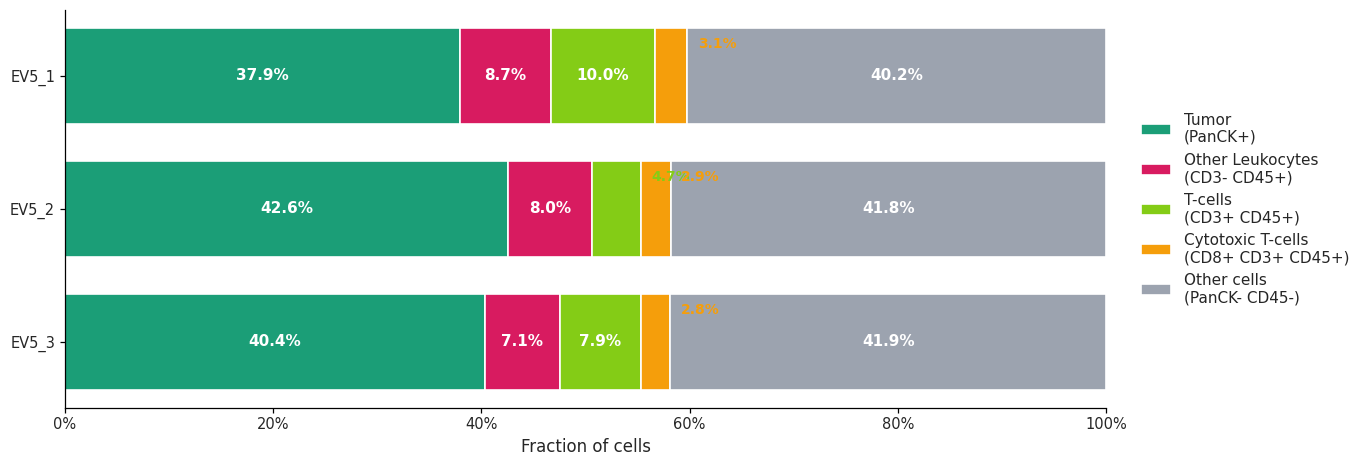

In [5]:
labels_pub = {
    "PanCK+": "Tumor\n(PanCK+)",
    "Other leukocytes": "Other Leukocytes\n(CD3- CD45+)",
    "CD3+ T-cells (non-CD8)": "T-cells\n(CD3+ CD45+)",
    "CD8+ Cytotoxic T-cells": "Cytotoxic T-cells\n(CD8+ CD3+ CD45+)",
    "Other": "Other cells\n(PanCK- CD45-)",
}

colors_pub = {
    "PanCK+": "#1b9e77",
    "Other leukocytes": "#d81b60",
    "CD3+ T-cells (non-CD8)": "#84cc16",
    "CD8+ Cytotoxic T-cells": "#f59e0b",
    "Other": "#9ca3af",
}

fig, ax = plot_publication_stacked_barh(
    meta_frac_pub[order_pub],
    title="",
    colors=colors_pub,
    labels_map=labels_pub,
    figsize=(14, 5),
    inside_threshold=0.06,
    outside_offset=0.010,
    x_label="Fraction of cells",
    save_path=ALL_SAMPLES_OUTDIR / "stacked_bar_chart_publication_ready.png",
    dpi=300,
)
plt.show()

In [6]:
# Export the exact data used for the EV5 stacked bar chart
stacked_counts = (
    df_plot
    .groupby("sample")["phenotype_meta"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=order_pub, fill_value=0)
)

stacked_counts.index = [sample_name_map.get(x, x) for x in stacked_counts.index]
stacked_fracs = stacked_counts.div(stacked_counts.sum(axis=1), axis=0)

pheno_name_map = {
    "PanCK+": "Tumor (PanCK+)",
    "Other leukocytes": "Leukocytes (CD45+)",
    "CD3+ T-cells (non-CD8)": "T-cells (CD3+ CD45+)",
    "CD8+ Cytotoxic T-cells": "Cytotoxic T-cells (CD8+ CD3+ CD45+)",
    "Other": "Other cells (PanCK- CD45-)",
}

stacked_export = pd.DataFrame(index=stacked_counts.index)
stacked_export["Total cells"] = stacked_counts.sum(axis=1)

for col in order_pub:
    pub_name = pheno_name_map[col]
    stacked_export[f"{pub_name} - count"] = stacked_counts[col]
    stacked_export[f"{pub_name} - fraction"] = stacked_fracs[col]

stacked_export = stacked_export.reindex(["EV5_1", "EV5_2", "EV5_3"])
display(stacked_export)

stacked_export.to_csv(
    ALL_SAMPLES_OUTDIR / "stacked_bar_chart_data_counts_and_fractions_publication_ready.csv",
    index=True,
)
print("Saved EV5 publication data to:", ALL_SAMPLES_OUTDIR)

,Total cells,Tumor (PanCK+) - count,Tumor (PanCK+) - fraction,Leukocytes (CD45+) - count,Leukocytes (CD45+) - fraction,T-cells (CD3+ CD45+) - count,T-cells (CD3+ CD45+) - fraction,Cytotoxic T-cells (CD8+ CD3+ CD45+) - count,Cytotoxic T-cells (CD8+ CD3+ CD45+) - fraction,Other cells (PanCK- CD45-) - count,Other cells (PanCK- CD45-) - fraction
EV5_1,502660,190634,0.379250,43806,0.087148,50384,0.100235,15630,0.031095,202206,0.402272
EV5_2,499229,212597,0.425851,40130,0.080384,23396,0.046864,14403,0.028850,208703,0.418051
EV5_3,504299,203656,0.403840,35929,0.071245,39632,0.078588,14027,0.027815,211055,0.418512


Saved EV5 publication data to: /home/sppipex/Desktop/SPU/Tony/IP031/analysis/all_samples_publication_outputs


## Part 2. ROI-level isPLA stacked bar charts (from `ispla_aluora`)

In [7]:
ISPLA_ANALYSIS_DIR = Path("/home/sppipex/Desktop/SPU/Tony/IP031/analysis/ispla_aluora")
ISPLA_OUTDIR = ISPLA_ANALYSIS_DIR / "downstream_results"
ISPLA_TABLE_DIR = ISPLA_OUTDIR / "final_summary_tables"
ISPLA_FIG_DIR = ISPLA_OUTDIR / "figures"

ISPLA_OUTDIR.mkdir(parents=True, exist_ok=True)
ISPLA_TABLE_DIR.mkdir(parents=True, exist_ok=True)
ISPLA_FIG_DIR.mkdir(parents=True, exist_ok=True)

roi_dirs = [
    ISPLA_ANALYSIS_DIR / "k1a_ispla_aluora" / "ROI_1",
    ISPLA_ANALYSIS_DIR / "k1a_ispla_aluora" / "ROI_2",
    ISPLA_ANALYSIS_DIR / "k1a_ispla_aluora" / "ROI_3",
    ISPLA_ANALYSIS_DIR / "hun-29-0160_ispla_aluora" / "ROI_1",
    ISPLA_ANALYSIS_DIR / "hun-29-0160_ispla_aluora" / "ROI_2",
    ISPLA_ANALYSIS_DIR / "hun-29-0160_ispla_aluora" / "ROI_3",
]

THRESHOLDS_ISPLA = {
    "CD3": 20.0,
    "CD8": 8.0,
    "CD45": 8.0,
    "PanCK": 10.0,
    "Nectin4": 10.0,
}

In [8]:
def parse_sample_and_roi(roi_dir):
    roi_dir = Path(roi_dir)
    roi = roi_dir.name
    sample = roi_dir.parent.name

    if "k1a" in sample.lower():
        tissue = "bladder"
    elif "hun" in sample.lower():
        tissue = "tonsil"
    else:
        tissue = "unknown"

    return sample, roi, tissue


def build_binary_marker_columns(df, thresholds):
    df = df.copy()
    for marker, thr in thresholds.items():
        if marker not in df.columns:
            raise ValueError(f"Marker column '{marker}' not found in dataframe.")
        df[f"{marker}_pos"] = df[marker] > thr
    return df


def assign_ispla_phenotype(row):
    # Immune-first hierarchy
    if row["CD45_pos"] and row["CD3_pos"] and row["CD8_pos"]:
        return "Cytotoxic_T_cell"
    elif row["CD45_pos"] and row["CD3_pos"] and not row["CD8_pos"]:
        return "T_cell"
    elif row["CD45_pos"] and not row["CD3_pos"]:
        return "Other_immune"

    # Non-immune compartment
    elif (not row["CD45_pos"]) and row["PanCK_pos"] and row["Nectin4_pos"]:
        return "Tumor_PanCK_Nectin4"
    elif (not row["CD45_pos"]) and row["PanCK_pos"] and (not row["Nectin4_pos"]):
        return "Tumor_PanCK_only"
    elif (not row["CD45_pos"]) and (not row["PanCK_pos"]) and row["Nectin4_pos"]:
        return "Nectin4_only"
    else:
        return "Other"


def summarize_roi_phenotypes(df):
    records = []
    group_cols = ["sample", "roi", "tissue"]

    for (sample, roi, tissue), sub in df.groupby(group_cols, dropna=False):
        total_cells = len(sub)

        for phenotype, pheno_sub in sub.groupby("phenotype", dropna=False):
            n_cells = len(pheno_sub)
            n_pos = int(pheno_sub["isPLA_positive"].sum())

            records.append({
                "sample": sample,
                "roi": roi,
                "tissue": tissue,
                "total_cells_roi": total_cells,
                "phenotype": phenotype,
                "n_cells": n_cells,
                "phenotype_fraction": n_cells / total_cells if total_cells > 0 else np.nan,
                "n_isPLA_positive": n_pos,
                "isPLA_fraction_within_phenotype": n_pos / n_cells if n_cells > 0 else np.nan,
                "mean_spots_per_cell": pheno_sub["isPLA_dots_spots_count"].mean(),
                "median_spots_per_cell": pheno_sub["isPLA_dots_spots_count"].median(),
                "mean_spots_per_positive_cell": pheno_sub.loc[
                    pheno_sub["isPLA_positive"], "isPLA_dots_spots_count"
                ].mean() if n_pos > 0 else 0,
                "median_spots_per_positive_cell": pheno_sub.loc[
                    pheno_sub["isPLA_positive"], "isPLA_dots_spots_count"
                ].median() if n_pos > 0 else 0,
            })

    return pd.DataFrame(records)


def relabel_roi_index(df):
    roi_label_map = {"ROI_1": "ROI 1", "ROI_2": "ROI 2", "ROI_3": "ROI 3"}
    out = df.copy()
    out.index = [
        roi_label_map.get(str(idx), str(idx).replace("ROI_", "ROI ").replace("_", " "))
        for idx in out.index
    ]
    return out


def relabel_pivot(df_pivot, rename_dict):
    df = df_pivot.copy()
    df.index = [rename_dict.get(i, i) for i in df.index]
    df.columns = [rename_dict.get(c, c) for c in df.columns]
    return df

In [9]:
all_dfs = []

for roi_dir in roi_dirs:
    cell_csv = roi_dir / "cell_data.csv"
    adata_file = roi_dir / "anndata.h5ad"

    sample, roi, tissue = parse_sample_and_roi(roi_dir)
    print(f"Loading {sample} | {roi}")

    cell_df = pd.read_csv(cell_csv).copy()
    if "cell_id" not in cell_df.columns:
        raise ValueError(f"'cell_id' missing in {cell_csv}")

    cell_df["cell_id"] = pd.to_numeric(cell_df["cell_id"], errors="coerce").astype("Int64")
    cell_df = cell_df.reset_index(drop=True)

    adata = ad.read_h5ad(adata_file)
    obs_df = adata.obs.copy().reset_index(drop=True)

    if "id" not in obs_df.columns:
        raise ValueError(f"'id' missing in adata.obs for {adata_file}")

    obs_df["id"] = pd.to_numeric(obs_df["id"], errors="coerce").astype("Int64")

    obs_keep = [
        "id",
        "isPLA_dots_spots_count",
        "isPLA_dots_spots_density",
        "isPLA_dots_clusters_count",
        "isPLA_dots_clusters_sum",
        "isPLA_dots_intensity_mean",
    ]
    obs_keep_existing = [c for c in obs_keep if c in obs_df.columns]
    obs_df = obs_df[obs_keep_existing].copy().rename(columns={"id": "cell_id"})

    merged = cell_df.merge(obs_df, on="cell_id", how="left")
    merged["sample"] = sample
    merged["roi"] = roi
    merged["tissue"] = tissue

    all_dfs.append(merged)

master_cells = pd.concat(all_dfs, ignore_index=True)

master_cells = build_binary_marker_columns(master_cells, THRESHOLDS_ISPLA)
master_cells["isPLA_positive"] = master_cells["isPLA_dots_spots_count"] >= 1
master_cells["phenotype"] = master_cells.apply(assign_ispla_phenotype, axis=1)

phenotype_order = [
    "Cytotoxic_T_cell",
    "T_cell",
    "Other_immune",
    "Tumor_PanCK_Nectin4",
    "Tumor_PanCK_only",
    "Nectin4_only",
    "Other",
]
master_cells["phenotype"] = pd.Categorical(
    master_cells["phenotype"],
    categories=phenotype_order,
    ordered=True,
)

roi_summary = summarize_roi_phenotypes(master_cells)

master_cells.to_csv(ISPLA_OUTDIR / "master_cells.csv", index=False)
roi_summary.to_csv(ISPLA_OUTDIR / "roi_phenotype_summary.csv", index=False)

display(master_cells[["sample", "roi", "phenotype", "isPLA_positive"]].head())
display(roi_summary.head())

Loading k1a_ispla_aluora | ROI_1
Loading k1a_ispla_aluora | ROI_2
Loading k1a_ispla_aluora | ROI_3
Loading hun-29-0160_ispla_aluora | ROI_1
Loading hun-29-0160_ispla_aluora | ROI_2
Loading hun-29-0160_ispla_aluora | ROI_3


/tmp/ipykernel_1147091/671430452.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for phenotype, pheno_sub in sub.groupby("phenotype", dropna=False):
/tmp/ipykernel_1147091/671430452.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for phenotype, pheno_sub in sub.groupby("phenotype", dropna=False):
/tmp/ipykernel_1147091/671430452.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for phenotype, pheno_sub in su

,sample,roi,phenotype,isPLA_positive
0,k1a_ispla_aluora,ROI_1,Other,False
1,k1a_ispla_aluora,ROI_1,Other_immune,False
2,k1a_ispla_aluora,ROI_1,Other_immune,False
3,k1a_ispla_aluora,ROI_1,Other,False
4,k1a_ispla_aluora,ROI_1,Other_immune,False


,sample,roi,tissue,total_cells_roi,phenotype,n_cells,phenotype_fraction,n_isPLA_positive,isPLA_fraction_within_phenotype,mean_spots_per_cell,median_spots_per_cell,mean_spots_per_positive_cell,median_spots_per_positive_cell
0,hun-29-0160_ispla_aluora,ROI_1,tonsil,9895,Cytotoxic_T_cell,1034,0.104497,147,0.142166,0.268859,0.0,1.891156,1.0
1,hun-29-0160_ispla_aluora,ROI_1,tonsil,9895,T_cell,3051,0.308338,994,0.325795,0.562439,0.0,1.726358,1.0
2,hun-29-0160_ispla_aluora,ROI_1,tonsil,9895,Other_immune,5147,0.520162,604,0.117350,0.159705,0.0,1.360927,1.0
3,hun-29-0160_ispla_aluora,ROI_1,tonsil,9895,Tumor_PanCK_Nectin4,4,0.000404,0,0.000000,0.000000,0.0,0.000000,0.0
4,hun-29-0160_ispla_aluora,ROI_1,tonsil,9895,Tumor_PanCK_only,2,0.000202,0,0.000000,0.000000,0.0,0.000000,0.0


In [10]:
pretty_names = {
    "Cytotoxic_T_cell": "Cytotoxic T-cells\n(CD8+ CD3+ CD45+)",
    "T_cell": "T-cells\n(CD3+ CD45+)",
    "Other_immune": "Other immune cells\n(CD45+ CD3-)",
    "isPLA+": "isPLA+",
    "isPLA-": "isPLA-",
}

immune_order = [
    "Cytotoxic_T_cell",
    "T_cell",
    "Other_immune",
]

immune_order_pretty = [
    "Cytotoxic T-cells\n(CD8+ CD3+ CD45+)",
    "T-cells\n(CD3+ CD45+)",
    "Other immune cells\n(CD45+ CD3-)",
]

immune_colors_pretty = {
    "Cytotoxic T-cells\n(CD8+ CD3+ CD45+)": "#F28E2B",
    "T-cells\n(CD3+ CD45+)": "#8BC34A",
    "Other immune cells\n(CD45+ CD3-)": "#D81B60",
}

binary_colors_pretty = {
    "isPLA-": "#1F3A5F",
    "isPLA+": "#F2C94C",
}

In [11]:
# 1) ROI-level isPLA status
roi_binary = (
    master_cells
    .groupby(["sample", "roi", "isPLA_positive"])
    .size()
    .rename("n_cells")
    .reset_index()
)

roi_binary["isPLA_status"] = np.where(roi_binary["isPLA_positive"], "isPLA+", "isPLA-")

roi_binary_pivot = roi_binary.pivot_table(
    index=["sample", "roi"],
    columns="isPLA_status",
    values="n_cells",
    fill_value=0,
)

for col in ["isPLA-", "isPLA+"]:
    if col not in roi_binary_pivot.columns:
        roi_binary_pivot[col] = 0

roi_binary_pivot = roi_binary_pivot[["isPLA-", "isPLA+"]]
roi_binary_frac = roi_binary_pivot.div(roi_binary_pivot.sum(axis=1), axis=0)

bladder_roi_binary = relabel_roi_index(roi_binary_frac.loc["k1a_ispla_aluora"].copy())
tonsil_roi_binary = relabel_roi_index(roi_binary_frac.loc["hun-29-0160_ispla_aluora"].copy())

display(bladder_roi_binary)
display(tonsil_roi_binary)

isPLA_status,isPLA-,isPLA+
ROI 1,0.972902,0.027098
ROI 2,0.966581,0.033419
ROI 3,0.973926,0.026074


isPLA_status,isPLA-,isPLA+
ROI 1,0.822739,0.177261
ROI 2,0.764595,0.235405
ROI 3,0.877672,0.122328


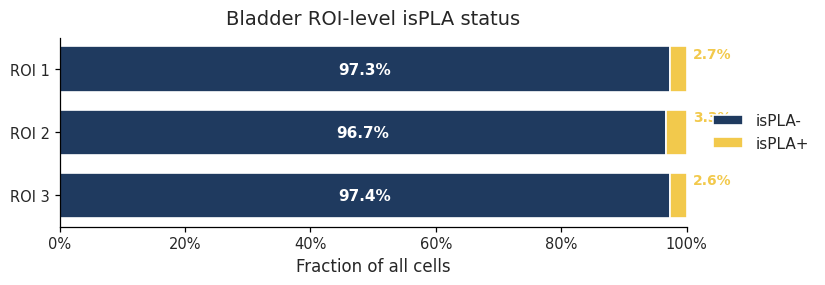

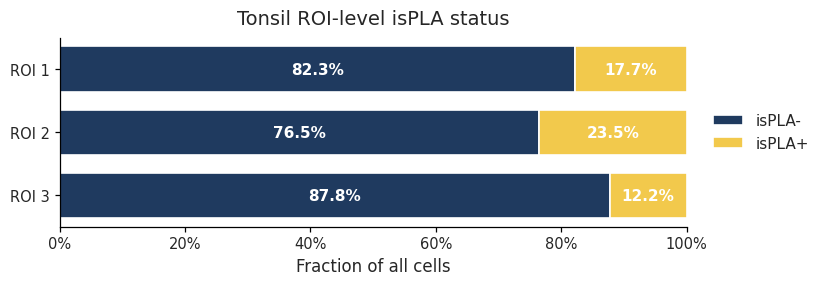

In [12]:
fig, ax = plot_publication_stacked_barh(
    bladder_roi_binary,
    title="Bladder ROI-level isPLA status",
    colors=binary_colors_pretty,
    figsize=(8.6, 3.2),
    inside_threshold=0.10,
    x_label="Fraction of all cells",
    save_path=ISPLA_FIG_DIR / "bladder_roi_level_ispla_status_300dpi.png",
    dpi=300,
)
plt.show()

fig, ax = plot_publication_stacked_barh(
    tonsil_roi_binary,
    title="Tonsil ROI-level isPLA status",
    colors=binary_colors_pretty,
    figsize=(8.6, 3.2),
    inside_threshold=0.10,
    x_label="Fraction of all cells",
    save_path=ISPLA_FIG_DIR / "tonsil_roi_level_ispla_status_300dpi.png",
    dpi=300,
)
plt.show()

bladder_roi_binary.to_csv(ISPLA_TABLE_DIR / "bladder_roi_level_ispla_status_data.csv")
tonsil_roi_binary.to_csv(ISPLA_TABLE_DIR / "tonsil_roi_level_ispla_status_data.csv")

In [13]:
# 2) ROI-level composition of isPLA+ immune cells
ispla_immune = master_cells[
    master_cells["phenotype"].isin(immune_order) &
    master_cells["isPLA_positive"]
].copy()

ispla_counts = (
    ispla_immune
    .groupby(["sample", "roi", "phenotype"])
    .size()
    .rename("n_cells")
    .reset_index()
)

pivot_ispla = ispla_counts.pivot_table(
    index=["sample", "roi"],
    columns="phenotype",
    values="n_cells",
    fill_value=0,
)

pivot_ispla = pivot_ispla.reindex(columns=immune_order, fill_value=0)
pivot_ispla_frac = pivot_ispla.div(pivot_ispla.sum(axis=1), axis=0)

bladder_ispla_plot = relabel_roi_index(pivot_ispla_frac.loc["k1a_ispla_aluora"].copy())
tonsil_ispla_plot = relabel_roi_index(pivot_ispla_frac.loc["hun-29-0160_ispla_aluora"].copy())

bladder_ispla_plot = relabel_pivot(bladder_ispla_plot, pretty_names)
tonsil_ispla_plot = relabel_pivot(tonsil_ispla_plot, pretty_names)

display(bladder_ispla_plot)
display(tonsil_ispla_plot)

/tmp/ipykernel_1147091/20917489.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sample", "roi", "phenotype"])


,Cytotoxic T-cells\n(CD8+ CD3+ CD45+),T-cells\n(CD3+ CD45+),Other immune cells\n(CD45+ CD3-)
ROI 1,0.100000,0.175000,0.725000
ROI 2,0.056604,0.245283,0.698113
ROI 3,0.119048,0.071429,0.809524


,Cytotoxic T-cells\n(CD8+ CD3+ CD45+),T-cells\n(CD3+ CD45+),Other immune cells\n(CD45+ CD3-)
ROI 1,0.084241,0.569628,0.346132
ROI 2,0.023266,0.333333,0.643400
ROI 3,0.105263,0.640486,0.254251


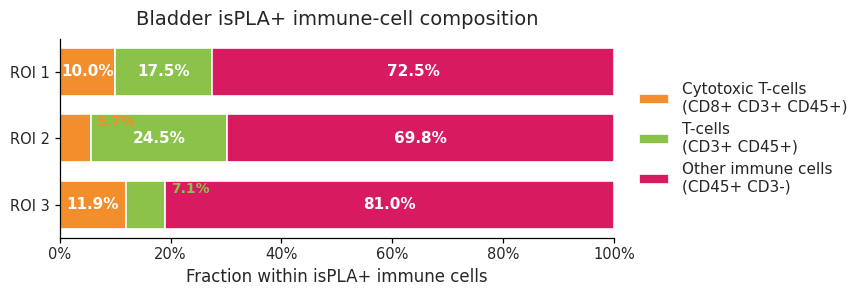

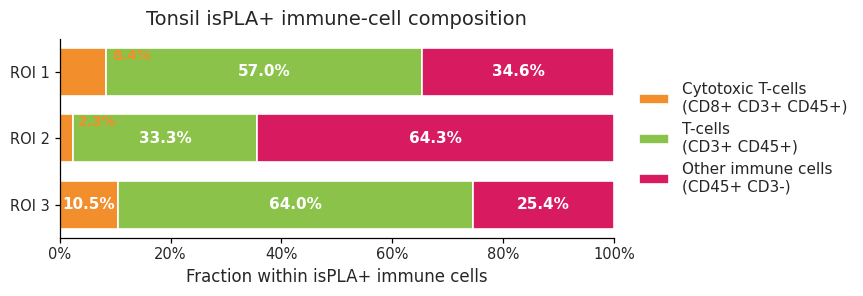

Saved isPLA outputs to:
/home/sppipex/Desktop/SPU/Tony/IP031/analysis/ispla_aluora/downstream_results


In [14]:
fig, ax = plot_publication_stacked_barh(
    bladder_ispla_plot[immune_order_pretty],
    title="Bladder isPLA+ immune-cell composition",
    colors=immune_colors_pretty,
    figsize=(9.0, 3.3),
    inside_threshold=0.10,
    outside_offset=0.010,
    x_label="Fraction within isPLA+ immune cells",
    save_path=ISPLA_FIG_DIR / "bladder_tls_ispla_immune_cells_comp_300dpi.png",
    dpi=300,
)
plt.show()

fig, ax = plot_publication_stacked_barh(
    tonsil_ispla_plot[immune_order_pretty],
    title="Tonsil isPLA+ immune-cell composition",
    colors=immune_colors_pretty,
    figsize=(9.0, 3.3),
    inside_threshold=0.10,
    outside_offset=0.010,
    x_label="Fraction within isPLA+ immune cells",
    save_path=ISPLA_FIG_DIR / "tonsil_gc_ispla_immune_cells_comp_300dpi.png",
    dpi=300,
)
plt.show()

bladder_ispla_plot[immune_order_pretty].to_csv(
    ISPLA_TABLE_DIR / "bladder_ispla_positive_immune_cell_composition_data.csv"
)
tonsil_ispla_plot[immune_order_pretty].to_csv(
    ISPLA_TABLE_DIR / "tonsil_ispla_positive_immune_cell_composition_data.csv"
)

print("Saved isPLA outputs to:")
print(ISPLA_OUTDIR)